<a href="https://colab.research.google.com/github/Ishrar436/CVPR/blob/main/CNN_22_49436_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading and Preprocessing

Dataset link :
https://www.kaggle.com/competitions/paddy-disease-classification/overview

Load dataset using PyTorch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Paths
BASE_DIR = "/content/drive/MyDrive/CVPR Dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train_images")
TEST_DIR  = os.path.join(BASE_DIR, "test_images")

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("TEST_DIR exists:", os.path.exists(TEST_DIR))

print("\nTrain class folders:")
print(sorted(os.listdir(TRAIN_DIR))[:20])

print("\nNumber of train class folders:", len(os.listdir(TRAIN_DIR)))
print("Number of test images:", len(os.listdir(TEST_DIR)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR exists: True
TRAIN_DIR exists: True
TEST_DIR exists: True

Train class folders:
['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']

Number of train class folders: 10
Number of test images: 3469


In [ ]:
import torch
from torchvision import datasets, transforms

IMG_SIZE = 128

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

In [ ]:
# Load dataset using PyTorch
full_dataset = datasets.ImageFolder(root=TRAIN_DIR)

class_names = full_dataset.classes
targets = full_dataset.targets

print("\nClasses:", class_names)
print("Number of classes:", len(class_names))
print("Total images:", len(full_dataset))


Classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Number of classes: 10
Total images: 10407


Create training and validation data loaders with batch size

In [ ]:
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# Settings
BATCH_SIZE = 32
SEED = 42

# Split into train and validation
indices = list(range(len(full_dataset)))

# Step 1: split into train (80%) and temp (20%)
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=targets,
    random_state=SEED
)

# Targets for temp split
temp_targets = [targets[i] for i in temp_idx]

# Step 2: split temp into validation (10%) and test (10%)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_targets,
    random_state=SEED
)

In [ ]:
# Apply transforms separately
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=TRAIN_DIR, transform=val_transform)
test_dataset  = datasets.ImageFolder(root=TRAIN_DIR, transform=val_transform)

# Create subsets
train_subset = Subset(train_dataset, train_idx)
val_subset   = Subset(val_dataset, val_idx)
test_subset  = Subset(test_dataset, test_idx)

In [ ]:
# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train samples:", len(train_subset))
print("Validation samples:", len(val_subset))
print("Test samples:", len(test_subset))

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train samples: 8325
Validation samples: 1041
Test samples: 1041
Train batches: 261
Validation batches: 33
Test batches: 33


# Model Architecture

Build a custom CNN

In [ ]:
# Model Architecture Setup

import torch
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(class_names)

print("Device:", DEVICE)
print("Number of classes:", NUM_CLASSES)

Device: cuda
Number of classes: 10


In [ ]:
# Custom CNN (Base Model)

class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()

        self.conv_layer1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv_layer2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv_layer3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv_layer1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv_layer2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv_layer3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.fc2(x)

        return x

In [ ]:
# Initialize the Base CNN

model_base = CustomCNN(num_classes=NUM_CLASSES).to(DEVICE)

print(model_base)

CustomCNN(
  (conv_layer1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_layer2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_layer3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


Try with and without batch normalization and dropout for regularization

In [ ]:
# Custom CNN with BatchNorm and Dropout

class CustomCNN_BN_Dropout(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN_BN_Dropout, self).__init__()

        self.conv_layer1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.25)

        self.conv_layer2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout(0.25)

        self.conv_layer3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout(0.25)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.relu4 = nn.ReLU()
        self.dropout_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv_layer1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.conv_layer2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        x = self.conv_layer3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        x = self.dropout3(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout_fc(x)
        x = self.fc2(x)

        return x

In [ ]:
# Initialize BN + Dropout CNN

model_bn_dropout = CustomCNN_BN_Dropout(num_classes=NUM_CLASSES).to(DEVICE)

print(model_bn_dropout)

CustomCNN_BN_Dropout(
  (conv_layer1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv_layer2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (conv_layer3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout(p=0.25, inplace=False)
  (flatten): F

In [ ]:
print("Base Model Ready:", model_base.__class__.__name__)
print("BN + Dropout Model Ready:", model_bn_dropout.__class__.__name__)

Base Model Ready: CustomCNN
BN + Dropout Model Ready: CustomCNN_BN_Dropout


Show Document architecture with a detailed summary

In [ ]:
!pip install -q torchinfo

In [ ]:
from torchinfo import summary

# Detailed Summary: Base CNN
summary(
    model_base,
    input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18,
    row_settings=["var_names"]
)
# Detailed Summary: BN + Dropout CNN
summary(
    model_bn_dropout,
    input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18,
    row_settings=["var_names"]
)

Layer (type (var_name))                       Input Shape        Output Shape       Param #            Trainable
CustomCNN_BN_Dropout (CustomCNN_BN_Dropout)   [32, 3, 128, 128]  [32, 10]           --                 True
├─Conv2d (conv_layer1)                        [32, 3, 128, 128]  [32, 32, 128, 128] 896                True
├─BatchNorm2d (bn1)                           [32, 32, 128, 128] [32, 32, 128, 128] 64                 True
├─ReLU (relu1)                                [32, 32, 128, 128] [32, 32, 128, 128] --                 --
├─MaxPool2d (pool1)                           [32, 32, 128, 128] [32, 32, 64, 64]   --                 --
├─Dropout (dropout1)                          [32, 32, 64, 64]   [32, 32, 64, 64]   --                 --
├─Conv2d (conv_layer2)                        [32, 32, 64, 64]   [32, 64, 64, 64]   18,496             True
├─BatchNorm2d (bn2)                           [32, 64, 64, 64]   [32, 64, 64, 64]   128                True
├─ReLU (relu2)               

In [ ]:
# Save summaries for later use

base_summary = summary(
    model_base,
    input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18,
    row_settings=["var_names"],
    verbose=0
)

bn_dropout_summary = summary(
    model_bn_dropout,
    input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18,
    row_settings=["var_names"],
    verbose=0
)

print("Base CNN Total Parameters       :", base_summary.total_params)
print("BN + Dropout CNN Total Parameters:", bn_dropout_summary.total_params)

Base CNN Total Parameters       : 8484682
BN + Dropout CNN Total Parameters: 8485130


In [ ]:
print("Model 1: CustomCNN (without BatchNorm and Dropout)")
print(" - 3 Convolution layers")
print(" - 3 ReLU activations")
print(" - 3 MaxPooling layers")
print(" - 2 Fully connected layers")
print(" - Final output layer for 10 classes")

print("\nModel 2: CustomCNN_BN_Dropout (with BatchNorm and Dropout)")
print(" - 3 Convolution layers")
print(" - 3 Batch Normalization layers")
print(" - 3 ReLU activations")
print(" - 3 MaxPooling layers")
print(" - 4 Dropout layers")
print(" - 2 Fully connected layers")
print(" - Final output layer for 10 classes")

Model 1: CustomCNN (without BatchNorm and Dropout)
 - 3 Convolution layers
 - 3 ReLU activations
 - 3 MaxPooling layers
 - 2 Fully connected layers
 - Final output layer for 10 classes

Model 2: CustomCNN_BN_Dropout (with BatchNorm and Dropout)
 - 3 Convolution layers
 - 3 Batch Normalization layers
 - 3 ReLU activations
 - 3 MaxPooling layers
 - 4 Dropout layers
 - 2 Fully connected layers
 - Final output layer for 10 classes


# Training and Optimization

Use appropriate optimizer (Adam, SGD)

In [ ]:
import torch.optim as optim

LEARNING_RATE = 0.001
print("Learning Rate:", LEARNING_RATE)

Learning Rate: 0.001


In [ ]:
# Adam optimizers
optimizer_base = optim.Adam(model_base.parameters(), lr=LEARNING_RATE)
optimizer_bn_dropout = optim.Adam(model_bn_dropout.parameters(), lr=LEARNING_RATE)

print("Base Model Optimizer       :", optimizer_base)
print("BN + Dropout Model Optimizer:", optimizer_bn_dropout)

Base Model Optimizer       : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
BN + Dropout Model Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
# Optional SGD optimizers (for comparison later if needed)
optimizer_base_sgd = optim.SGD(model_base.parameters(), lr=0.01, momentum=0.9)
optimizer_bn_dropout_sgd = optim.SGD(model_bn_dropout.parameters(), lr=0.01, momentum=0.9)

print("Base Model SGD Optimizer       :", optimizer_base_sgd)
print("BN + Dropout Model SGD Optimizer:", optimizer_bn_dropout_sgd)

Base Model SGD Optimizer       : SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)
BN + Dropout Model SGD Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


Implement learning rate scheduling

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Import scheduler and define settings
FACTOR = 0.5
PATIENCE = 2

print("Scheduler Factor   :", FACTOR)
print("Scheduler Patience :", PATIENCE)

Scheduler Factor   : 0.5
Scheduler Patience : 2


In [ ]:
# Create schedulers for both Adam optimizers
scheduler_base = ReduceLROnPlateau(
    optimizer_base,
    mode='min',
    factor=FACTOR,
    patience=PATIENCE
)

scheduler_bn_dropout = ReduceLROnPlateau(
    optimizer_bn_dropout,
    mode='min',
    factor=FACTOR,
    patience=PATIENCE
)

print("Base Model Scheduler       :", scheduler_base)
print("BN + Dropout Model Scheduler:", scheduler_bn_dropout)

Base Model Scheduler       : <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x799e9c5669c0>
BN + Dropout Model Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x799e9c564bf0>


Use cross-entropy loss for multi-class classification

In [ ]:
import torch.nn as nn

# Define the loss function
criterion = nn.CrossEntropyLoss()

print("Loss Function:", criterion)

Loss Function: CrossEntropyLoss()


In [ ]:
# Keep separate names for both models
criterion_base = nn.CrossEntropyLoss()
criterion_bn_dropout = nn.CrossEntropyLoss()

print("Base Model Loss Function       :", criterion_base)
print("BN + Dropout Model Loss Function:", criterion_bn_dropout)

Base Model Loss Function       : CrossEntropyLoss()
BN + Dropout Model Loss Function: CrossEntropyLoss()


Training and Validation

In [ ]:
# Training Settings
EPOCHS = 10

print("Training Device:", DEVICE)
print("Epochs:", EPOCHS)

Training Device: cuda
Epochs: 10


In [ ]:
# Train One Epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
# Validate One Epoch
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
# Full Training Loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [ ]:
# Train Base CNN
history_base = train_model(
    model=model_base,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_base,
    optimizer=optimizer_base,
    scheduler=scheduler_base,
    device=DEVICE,
    epochs=EPOCHS
)

Epoch [1/10] Train Loss: 1.9245 | Train Acc: 0.3174 | Val Loss: 1.7909 | Val Acc: 0.3545
Epoch [2/10] Train Loss: 1.5667 | Train Acc: 0.4553 | Val Loss: 1.4207 | Val Acc: 0.5130
Epoch [3/10] Train Loss: 1.2956 | Train Acc: 0.5582 | Val Loss: 1.2640 | Val Acc: 0.5860
Epoch [4/10] Train Loss: 1.0531 | Train Acc: 0.6519 | Val Loss: 0.9855 | Val Acc: 0.6907
Epoch [5/10] Train Loss: 0.8474 | Train Acc: 0.7218 | Val Loss: 0.8351 | Val Acc: 0.7406
Epoch [6/10] Train Loss: 0.6797 | Train Acc: 0.7786 | Val Loss: 0.7215 | Val Acc: 0.7887
Epoch [7/10] Train Loss: 0.5361 | Train Acc: 0.8315 | Val Loss: 0.6255 | Val Acc: 0.8127
Epoch [8/10] Train Loss: 0.4438 | Train Acc: 0.8604 | Val Loss: 0.5677 | Val Acc: 0.8434
Epoch [9/10] Train Loss: 0.3606 | Train Acc: 0.8847 | Val Loss: 0.5704 | Val Acc: 0.8338
Epoch [10/10] Train Loss: 0.2898 | Train Acc: 0.9082 | Val Loss: 0.5717 | Val Acc: 0.8444


In [ ]:
# Train BN + Dropout CNN
history_bn_dropout = train_model(
    model=model_bn_dropout,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_bn_dropout,
    optimizer=optimizer_bn_dropout,
    scheduler=scheduler_bn_dropout,
    device=DEVICE,
    epochs=EPOCHS
)

Epoch [1/10] Train Loss: 2.7704 | Train Acc: 0.2181 | Val Loss: 2.0973 | Val Acc: 0.2997
Epoch [2/10] Train Loss: 2.0656 | Train Acc: 0.2553 | Val Loss: 1.8790 | Val Acc: 0.3477
Epoch [3/10] Train Loss: 1.9951 | Train Acc: 0.2709 | Val Loss: 1.9071 | Val Acc: 0.3324
Epoch [4/10] Train Loss: 1.9659 | Train Acc: 0.2792 | Val Loss: 1.8853 | Val Acc: 0.3622
Epoch [5/10] Train Loss: 1.9367 | Train Acc: 0.2804 | Val Loss: 1.7387 | Val Acc: 0.3708
Epoch [6/10] Train Loss: 1.9088 | Train Acc: 0.2929 | Val Loss: 1.7986 | Val Acc: 0.3333
Epoch [7/10] Train Loss: 1.9051 | Train Acc: 0.2884 | Val Loss: 1.7126 | Val Acc: 0.4006
Epoch [8/10] Train Loss: 1.8826 | Train Acc: 0.3003 | Val Loss: 1.7591 | Val Acc: 0.4025
Epoch [9/10] Train Loss: 1.8425 | Train Acc: 0.3164 | Val Loss: 1.7135 | Val Acc: 0.3996
Epoch [10/10] Train Loss: 1.8416 | Train Acc: 0.3229 | Val Loss: 1.6275 | Val Acc: 0.4217


Plot training and validation loss/accuracy curves

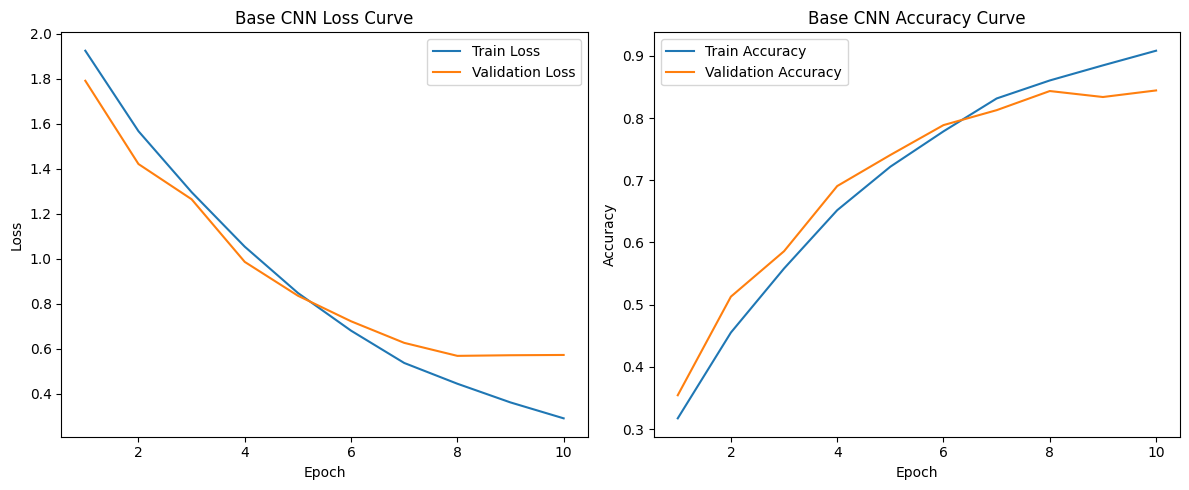

In [ ]:
import matplotlib.pyplot as plt

# Plot Curves: Base CNN
epochs_range = range(1, len(history_base["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_base["train_loss"], label="Train Loss")
plt.plot(epochs_range, history_base["val_loss"], label="Validation Loss")
plt.title("Base CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_base["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history_base["val_acc"], label="Validation Accuracy")
plt.title("Base CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

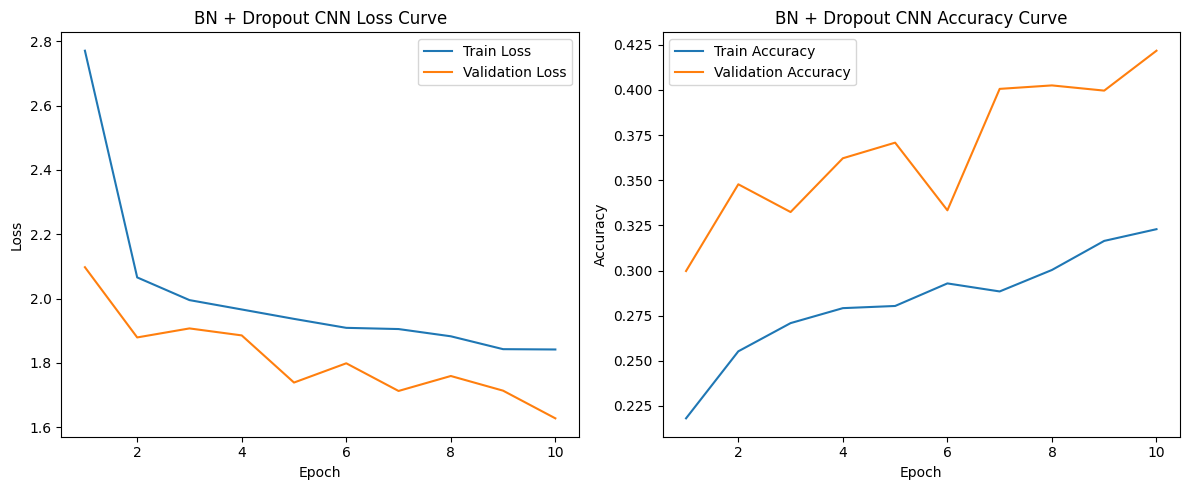

In [ ]:
# Plot Curves: BN + Dropout CNN
epochs_range = range(1, len(history_bn_dropout["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_bn_dropout["train_loss"], label="Train Loss")
plt.plot(epochs_range, history_bn_dropout["val_loss"], label="Validation Loss")
plt.title("BN + Dropout CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_bn_dropout["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history_bn_dropout["val_acc"], label="Validation Accuracy")
plt.title("BN + Dropout CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

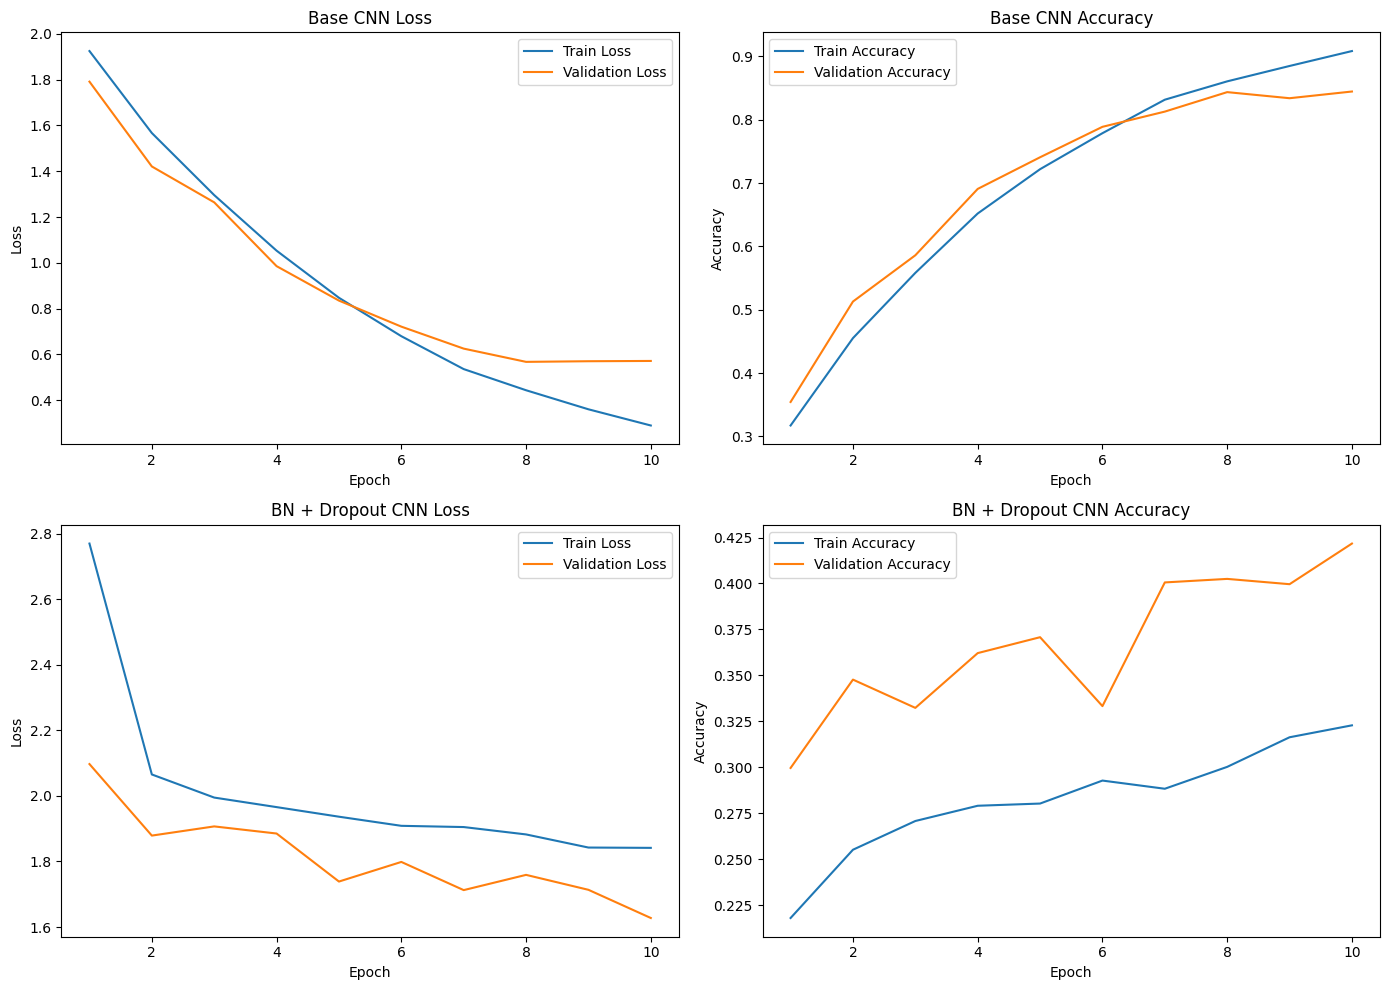

In [ ]:
# Combined Comparison Plot
epochs_range = range(1, len(history_base["train_loss"]) + 1)

plt.figure(figsize=(14, 10))

# Base Model Loss
plt.subplot(2, 2, 1)
plt.plot(epochs_range, history_base["train_loss"], label="Train Loss")
plt.plot(epochs_range, history_base["val_loss"], label="Validation Loss")
plt.title("Base CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Base Model Accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs_range, history_base["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history_base["val_acc"], label="Validation Accuracy")
plt.title("Base CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# BN + Dropout Loss
plt.subplot(2, 2, 3)
plt.plot(epochs_range, history_bn_dropout["train_loss"], label="Train Loss")
plt.plot(epochs_range, history_bn_dropout["val_loss"], label="Validation Loss")
plt.title("BN + Dropout CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# BN + Dropout Accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs_range, history_bn_dropout["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history_bn_dropout["val_acc"], label="Validation Accuracy")
plt.title("BN + Dropout CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Model Evaluation

Evaluate on test set and report comprehensive metrics

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
# Evaluate Model on Test Set

def evaluate_model_on_test(model, test_loader, criterion, device, class_names):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    test_loss = running_loss / len(test_loader.dataset)
    test_accuracy = accuracy_score(all_labels, all_preds)
    test_precision_macro = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    test_recall_macro = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    test_f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    test_precision_weighted = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    test_recall_weighted = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    test_f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    class_report_text = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        zero_division=0
    )

    class_report_dict = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds)

    results = {
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "test_precision_macro": test_precision_macro,
        "test_recall_macro": test_recall_macro,
        "test_f1_macro": test_f1_macro,
        "test_precision_weighted": test_precision_weighted,
        "test_recall_weighted": test_recall_weighted,
        "test_f1_weighted": test_f1_weighted,
        "classification_report_text": class_report_text,
        "classification_report_dict": class_report_dict,
        "confusion_matrix": cm,
        "y_true": all_labels,
        "y_pred": all_preds
    }

    return results

In [ ]:
# Test Evaluation: Base CNN

base_test_results = evaluate_model_on_test(
    model=model_base,
    test_loader=test_loader,
    criterion=criterion_base,
    device=DEVICE,
    class_names=class_names
)

print("Base CNN Test Loss           :", round(base_test_results["test_loss"], 4))
print("Base CNN Test Accuracy       :", round(base_test_results["test_accuracy"], 4))
print("Base CNN Precision (Macro)   :", round(base_test_results["test_precision_macro"], 4))
print("Base CNN Recall (Macro)      :", round(base_test_results["test_recall_macro"], 4))
print("Base CNN F1 Score (Macro)    :", round(base_test_results["test_f1_macro"], 4))
print("Base CNN Precision (Weighted):", round(base_test_results["test_precision_weighted"], 4))
print("Base CNN Recall (Weighted)   :", round(base_test_results["test_recall_weighted"], 4))
print("Base CNN F1 Score (Weighted) :", round(base_test_results["test_f1_weighted"], 4))

print("\nClassification Report for Base CNN:\n")
print(base_test_results["classification_report_text"])

Base CNN Test Loss           : 0.6162
Base CNN Test Accuracy       : 0.8204
Base CNN Precision (Macro)   : 0.808
Base CNN Recall (Macro)      : 0.8071
Base CNN F1 Score (Macro)    : 0.8023
Base CNN Precision (Weighted): 0.8313
Base CNN Recall (Weighted)   : 0.8204
Base CNN F1 Score (Weighted) : 0.8219

Classification Report for Base CNN:

                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.79      0.77      0.78        48
   bacterial_leaf_streak       0.67      0.92      0.78        38
bacterial_panicle_blight       0.82      0.70      0.75        33
                   blast       0.84      0.87      0.86       174
              brown_spot       0.65      0.84      0.73        97
              dead_heart       0.95      0.88      0.91       144
            downy_mildew       0.79      0.66      0.72        62
                   hispa       0.77      0.84      0.81       160
                  normal       0.90      0.76      0.82       17

In [ ]:
# Test Evaluation: BN + Dropout CNN

bn_dropout_test_results = evaluate_model_on_test(
    model=model_bn_dropout,
    test_loader=test_loader,
    criterion=criterion_bn_dropout,
    device=DEVICE,
    class_names=class_names
)

print("BN + Dropout CNN Test Loss           :", round(bn_dropout_test_results["test_loss"], 4))
print("BN + Dropout CNN Test Accuracy       :", round(bn_dropout_test_results["test_accuracy"], 4))
print("BN + Dropout CNN Precision (Macro)   :", round(bn_dropout_test_results["test_precision_macro"], 4))
print("BN + Dropout CNN Recall (Macro)      :", round(bn_dropout_test_results["test_recall_macro"], 4))
print("BN + Dropout CNN F1 Score (Macro)    :", round(bn_dropout_test_results["test_f1_macro"], 4))
print("BN + Dropout CNN Precision (Weighted):", round(bn_dropout_test_results["test_precision_weighted"], 4))
print("BN + Dropout CNN Recall (Weighted)   :", round(bn_dropout_test_results["test_recall_weighted"], 4))
print("BN + Dropout CNN F1 Score (Weighted) :", round(bn_dropout_test_results["test_f1_weighted"], 4))

print("\nClassification Report for BN + Dropout CNN:\n")
print(bn_dropout_test_results["classification_report_text"])

BN + Dropout CNN Test Loss           : 1.6112
BN + Dropout CNN Test Accuracy       : 0.4332
BN + Dropout CNN Precision (Macro)   : 0.2949
BN + Dropout CNN Recall (Macro)      : 0.2813
BN + Dropout CNN F1 Score (Macro)    : 0.2375
BN + Dropout CNN Precision (Weighted): 0.3898
BN + Dropout CNN Recall (Weighted)   : 0.4332
BN + Dropout CNN F1 Score (Weighted) : 0.3566

Classification Report for BN + Dropout CNN:

                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.00      0.00      0.00        48
   bacterial_leaf_streak       0.00      0.00      0.00        38
bacterial_panicle_blight       0.00      0.00      0.00        33
                   blast       0.36      0.65      0.46       174
              brown_spot       0.80      0.04      0.08        97
              dead_heart       0.70      0.85      0.76       144
            downy_mildew       0.00      0.00      0.00        62
                   hispa       0.25      0.35      0.29  

In [ ]:
# Compare Both Models on Test Set

comparison_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Test Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
        "Precision Weighted",
        "Recall Weighted",
        "F1 Weighted"
    ],
    "Base CNN": [
        base_test_results["test_loss"],
        base_test_results["test_accuracy"],
        base_test_results["test_precision_macro"],
        base_test_results["test_recall_macro"],
        base_test_results["test_f1_macro"],
        base_test_results["test_precision_weighted"],
        base_test_results["test_recall_weighted"],
        base_test_results["test_f1_weighted"]
    ],
    "BN + Dropout CNN": [
        bn_dropout_test_results["test_loss"],
        bn_dropout_test_results["test_accuracy"],
        bn_dropout_test_results["test_precision_macro"],
        bn_dropout_test_results["test_recall_macro"],
        bn_dropout_test_results["test_f1_macro"],
        bn_dropout_test_results["test_precision_weighted"],
        bn_dropout_test_results["test_recall_weighted"],
        bn_dropout_test_results["test_f1_weighted"]
    ]
})

comparison_df

,Metric,Base CNN,BN + Dropout CNN
0,Test Loss,0.616199,1.611186
1,Test Accuracy,0.820365,0.433237
2,Precision Macro,0.807960,0.294902
3,Recall Macro,0.807148,0.281267
4,F1 Macro,0.802330,0.237475
5,Precision Weighted,0.831315,0.389757
6,Recall Weighted,0.820365,0.433237
7,F1 Weighted,0.821905,0.356596


Generate confusion matrix visualization

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix Plot Function

def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

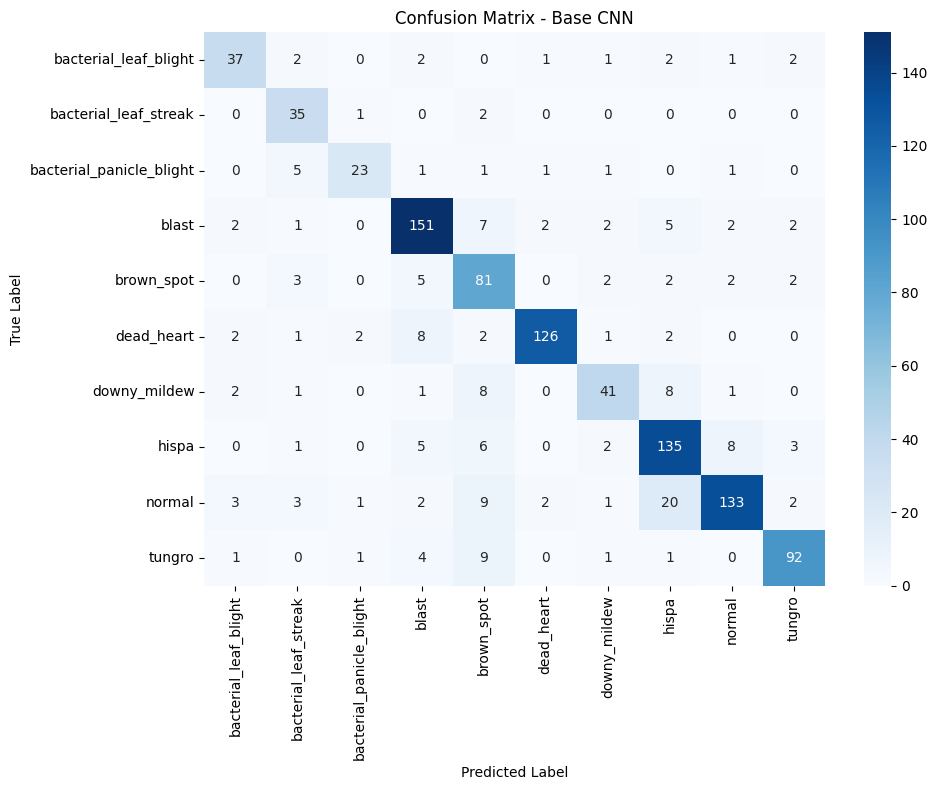

In [ ]:
# Confusion Matrix: Base CNN

plot_confusion_matrix(
    base_test_results["confusion_matrix"],
    class_names,
    "Confusion Matrix - Base CNN"
)

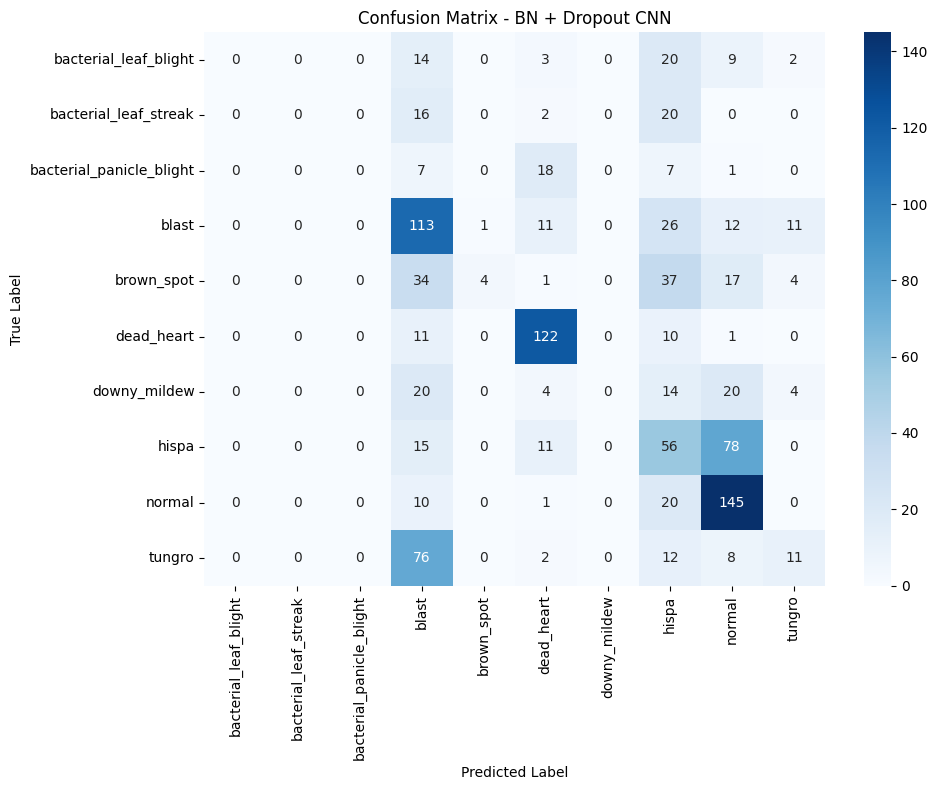

In [ ]:
# Confusion Matrix: BN + Dropout CNN

plot_confusion_matrix(
    bn_dropout_test_results["confusion_matrix"],
    class_names,
    "Confusion Matrix - BN + Dropout CNN"
)

Analyze per-class performance (best and worst performing classes)

In [ ]:
# Per-Class Performance Function

def get_per_class_df(report_dict):
    df = pd.DataFrame(report_dict).transpose()

    # remove overall rows
    df = df.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")

    return df

In [ ]:
# Per-Class Analysis: Base CNN

base_class_df = get_per_class_df(base_test_results["classification_report_dict"])

print("Base CNN Per-Class Performance:\n")
display(base_class_df)

best_base_class = base_class_df["f1-score"].idxmax()
worst_base_class = base_class_df["f1-score"].idxmin()

print("Best Performing Class (Base CNN) :", best_base_class)
print("Worst Performing Class (Base CNN):", worst_base_class)

Base CNN Per-Class Performance:



,precision,recall,f1-score,support
bacterial_leaf_blight,0.787234,0.770833,0.778947,48.0
bacterial_leaf_streak,0.673077,0.921053,0.777778,38.0
bacterial_panicle_blight,0.821429,0.696970,0.754098,33.0
blast,0.843575,0.867816,0.855524,174.0
brown_spot,0.648000,0.835052,0.729730,97.0
dead_heart,0.954545,0.875000,0.913043,144.0
downy_mildew,0.788462,0.661290,0.719298,62.0
hispa,0.771429,0.843750,0.805970,160.0
normal,0.898649,0.755682,0.820988,176.0
tungro,0.893204,0.844037,0.867925,109.0


Best Performing Class (Base CNN) : dead_heart
Worst Performing Class (Base CNN): downy_mildew


In [ ]:
# Per-Class Analysis: BN + Dropout CNN

bn_class_df = get_per_class_df(bn_dropout_test_results["classification_report_dict"])

print("BN + Dropout CNN Per-Class Performance:\n")
display(bn_class_df)

best_bn_class = bn_class_df["f1-score"].idxmax()
worst_bn_class = bn_class_df["f1-score"].idxmin()

print("Best Performing Class (BN + Dropout CNN) :", best_bn_class)
print("Worst Performing Class (BN + Dropout CNN):", worst_bn_class)

BN + Dropout CNN Per-Class Performance:



,precision,recall,f1-score,support
bacterial_leaf_blight,0.000000,0.000000,0.000000,48.0
bacterial_leaf_streak,0.000000,0.000000,0.000000,38.0
bacterial_panicle_blight,0.000000,0.000000,0.000000,33.0
blast,0.357595,0.649425,0.461224,174.0
brown_spot,0.800000,0.041237,0.078431,97.0
dead_heart,0.697143,0.847222,0.764890,144.0
downy_mildew,0.000000,0.000000,0.000000,62.0
hispa,0.252252,0.350000,0.293194,160.0
normal,0.498282,0.823864,0.620985,176.0
tungro,0.343750,0.100917,0.156028,109.0


Best Performing Class (BN + Dropout CNN) : dead_heart
Worst Performing Class (BN + Dropout CNN): bacterial_leaf_blight


In [ ]:
print("Base CNN -> Best Class :", best_base_class, "| Worst Class :", worst_base_class)
print("BN + Dropout CNN -> Best Class :", best_bn_class, "| Worst Class :", worst_bn_class)

Base CNN -> Best Class : dead_heart | Worst Class : downy_mildew
BN + Dropout CNN -> Best Class : dead_heart | Worst Class : bacterial_leaf_blight


Save trained model weights

In [ ]:
# Create Save Directory

SAVE_DIR = os.path.join(BASE_DIR, "saved_models")
os.makedirs(SAVE_DIR, exist_ok=True)

print("Save Directory:", SAVE_DIR)

Save Directory: /content/drive/MyDrive/CVPR Dataset/saved_models


In [ ]:
# Save Base CNN Weights

base_model_path = os.path.join(SAVE_DIR, "customcnn_base.pth")
torch.save(model_base.state_dict(), base_model_path)

print("Base CNN weights saved to:", base_model_path)

Base CNN weights saved to: /content/drive/MyDrive/CVPR Dataset/saved_models/customcnn_base.pth


In [ ]:
# Save BN + Dropout CNN Weights

bn_dropout_model_path = os.path.join(SAVE_DIR, "customcnn_bn_dropout.pth")
torch.save(model_bn_dropout.state_dict(), bn_dropout_model_path)

print("BN + Dropout CNN weights saved to:", bn_dropout_model_path)

BN + Dropout CNN weights saved to: /content/drive/MyDrive/CVPR Dataset/saved_models/customcnn_bn_dropout.pth


In [ ]:
print("Saved files:")
print("-", base_model_path)
print("-", bn_dropout_model_path)

Saved files:
- /content/drive/MyDrive/CVPR Dataset/saved_models/customcnn_base.pth
- /content/drive/MyDrive/CVPR Dataset/saved_models/customcnn_bn_dropout.pth


Saved model link :
https://drive.google.com/drive/folders/1UAg3PLKo_93y8cz29Nlf2UAbwDOmdfPc?dmr=1&ec=wgc-drive-%5Bmodule%5D-goto